In [5]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from src.models import KovaDeepONet
from src.utils import load_losses, kova_solution_np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
model = KovaDeepONet(256).double()
model.load_state_dict(torch.load('../models/deepo/model_5/DON_kova.pt'))
model.eval()

KovaDeepONet(
  (trunk_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1-4): 4 x Linear(in_features=128, out_features=128, bias=True)
      (5): Linear(in_features=128, out_features=256, bias=True)
    )
  )
  (branch_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1-4): 4 x Linear(in_features=128, out_features=128, bias=True)
      (5): Linear(in_features=128, out_features=768, bias=True)
    )
  )
)

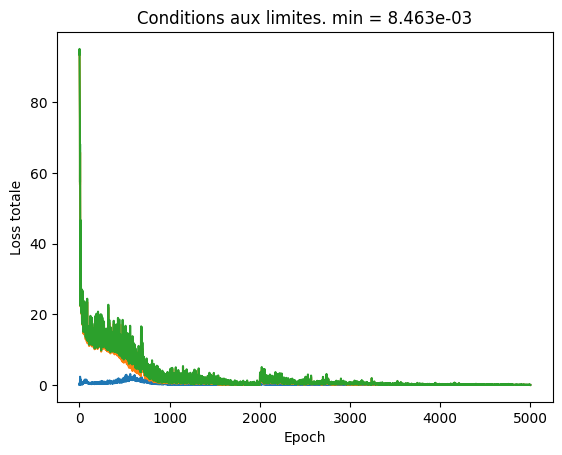

In [30]:
losses = load_losses('../models/deepo/model_5/losses_09.json')


lines = plt.plot(losses)

plt.xlabel('Epoch')
plt.ylabel('Loss totale')
plt.title(f'Conditions aux limites. min = {losses[:, 1].min():.3e}')
plt.show()

In [8]:
inside_points = np.column_stack((np.random.uniform(-0.5, 1.0, 2000), np.random.uniform(-0.5, 1.5, 2000)))
outside_points = np.array([[-0.5, i] for i in np.linspace(-0.5, 1.5, 50)] + [[1, i] for i in np.linspace(-0.5, 1.5, 50)] + [[i, -0.5] for i in np.linspace(-0.5, 1, 50)] + [[i, 1.5] for i in np.linspace(-0.5, 1, 50)])

In [9]:
with torch.no_grad():
    re = torch.tensor([34], dtype=torch.double)
    inside_results = model(re, torch.tensor(inside_points, dtype=torch.double)).squeeze(0)
    outside_results = model(re, torch.tensor(outside_points, dtype=torch.double)).squeeze(0)


In [10]:
inside_true_results = kova_solution_np(inside_points[:, 0], inside_points[:, 1], 1/34)
outside_true_results = kova_solution_np(outside_points[:, 0], outside_points[:, 1], 1/34)

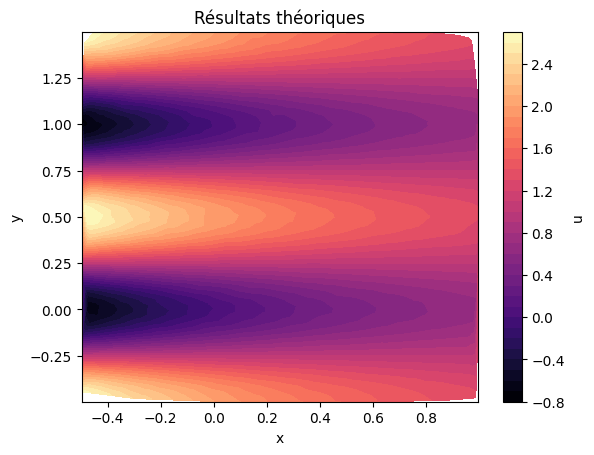

In [11]:
plt.tricontourf(inside_points[:, 0], inside_points[:, 1], inside_true_results[:, 0],levels=40, cmap='magma')
plt.colorbar(label='u')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Résultats théoriques')
plt.show()

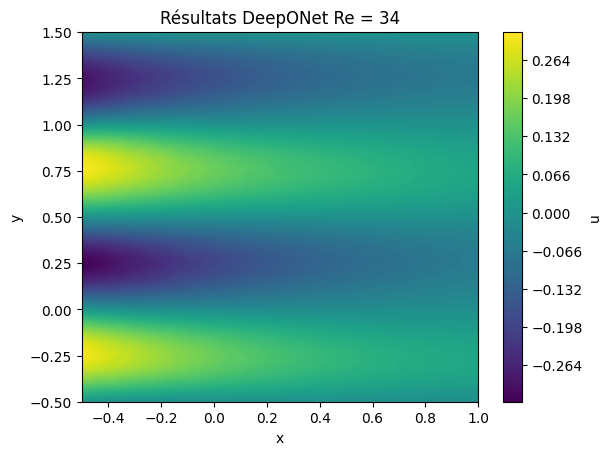

In [20]:
plt.tricontourf(np.concatenate((inside_points[:, 0], outside_points[:, 0])), np.concatenate((inside_points[:, 1], outside_points[:, 1])), np.concatenate((inside_results[:, 1], outside_results[:, 1])),levels=250, cmap='viridis')
plt.colorbar(label='u')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Résultats DeepONet Re = 34')
plt.show()

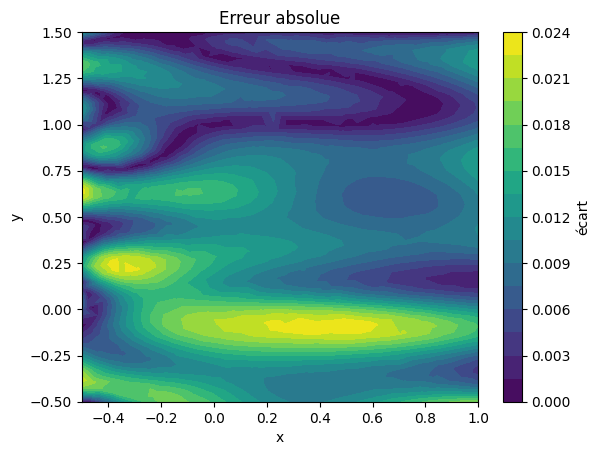

In [19]:
plt.tricontourf(
    np.concatenate((inside_points[:, 0], outside_points[:, 0])),
    np.concatenate((inside_points[:, 1], outside_points[:, 1])),
    np.concatenate((
        np.abs(inside_results[:, 1] - inside_true_results[:, 1]),
        np.abs(outside_results[:, 1] - outside_true_results[:, 1]))
    ),
    levels=20,
    cmap='viridis'
)
plt.colorbar(label='écart')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Erreur absolue')
plt.show()

In [14]:
def get_result(Re):
    return

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def kovasznay(Re, x, y):
    lam = Re/2 - np.sqrt(Re**2/4 + 4*np.pi**2)
    u = 1 - np.exp(lam*x) * np.cos(2*np.pi*y)
    v = lam/(2*np.pi) * np.exp(lam*x) * np.sin(2*np.pi*y)
    p = 0.5*(1 - np.exp(2*lam*x))
    return u, v, p

def l2rel(pred, ref):
    return np.linalg.norm(pred - ref) / (np.linalg.norm(ref) + 1e-14)

x1d = np.linspace(-0.5, 1.0, 100)
y1d = np.linspace(-0.5, 1.5, 100)
X, Y = np.meshgrid(x1d, y1d)

RE_LIST = np.linspace(5, 200, 30).tolist()

def is_extrap(Re): return Re < 20 or Re > 100

# Précalcul des erreurs
errors = {'u': [], 'v': [], 'p': []}
matrix = np.zeros((3, len(RE_LIST)))

for j, Re in enumerate(RE_LIST):
    preds = model(
        torch.tensor([Re], dtype=torch.float64),
        torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float64)
    )
    refs  = kovasznay(Re, X, Y)
    for i, (pred, ref) in enumerate(zip(preds.detach().T, refs)):
        pred_np = pred.numpy().reshape(X.shape)
        errors[['u','v','p'][i]].append(l2rel(pred_np, ref))
        matrix[i, j] = errors[['u','v','p'][i]][-1]

box_data_fields = {name: [] for name in ['u','v','p']}
for j, Re in enumerate(RE_LIST):
    f = model
    preds = f(
        torch.tensor([Re], dtype=torch.float64),
        torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float64)
    ).detach()
    refs = kovasznay(Re, X, Y)
    for i, name in enumerate(['u','v','p']):
        err = np.abs(preds[:,i].numpy().reshape(X.shape) - refs[i]).ravel()
        box_data_fields[name].append(err)

ValueError: cannot reshape array of size 3 into shape (100,100)

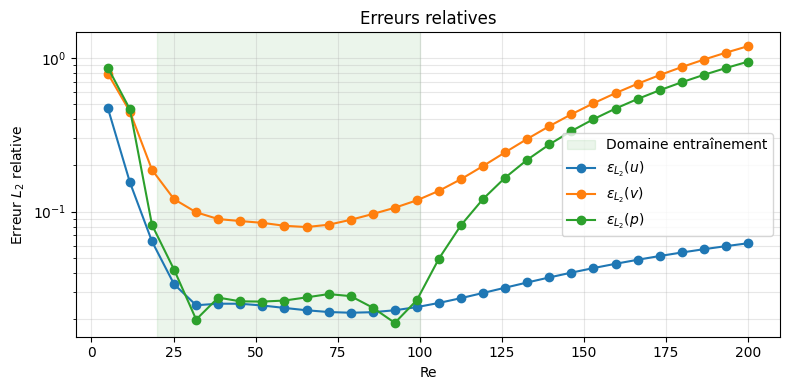

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(20, 100, color='green', alpha=0.08, label='Domaine entraînement')
for field, color in zip(['u','v','p'], ['#1f77b4','#ff7f0e','#2ca02c']):
    ax.plot(RE_LIST, errors[field], 'o-', color=color, label=f'$\\epsilon_{{L_2}}({field})$')
ax.set_yscale('log')
ax.set_xlabel('Re'); ax.set_ylabel('Erreur $L_2$ relative')
ax.set_title('Erreurs relatives')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

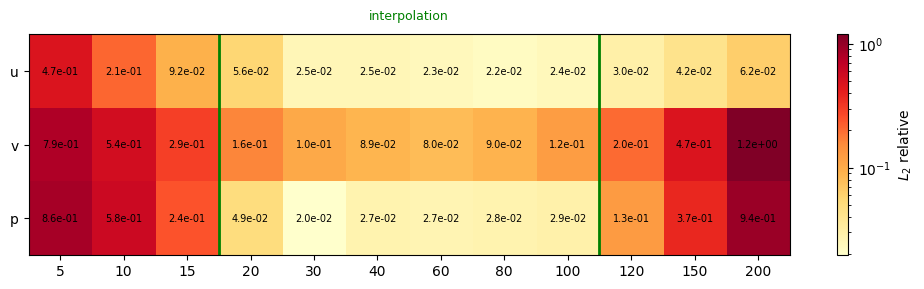

In [17]:
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd',
               norm=plt.matplotlib.colors.LogNorm(vmin=matrix.min(), vmax=matrix.max()))
ax.set_xticks(range(len(RE_LIST))); ax.set_xticklabels(RE_LIST)
ax.set_yticks(range(3)); ax.set_yticklabels(['u','v','p'])
plt.colorbar(im, ax=ax, label='$L_2$ relative')
j_in = [j for j, Re in enumerate(RE_LIST) if not is_extrap(Re)]
ax.axvline(min(j_in)-.5, color='green', lw=2)
ax.axvline(max(j_in)+.5, color='green', lw=2)
ax.text((min(j_in)+max(j_in))/2, -.7, 'interpolation', ha='center', color='green', fontsize=9)
for i in range(3):
    for j in range(len(RE_LIST)):
        ax.text(j, i, f'{matrix[i,j]:.1e}', ha='center', va='center', fontsize=7)
plt.tight_layout(); plt.show()

TypeError: 'NoneType' object is not callable

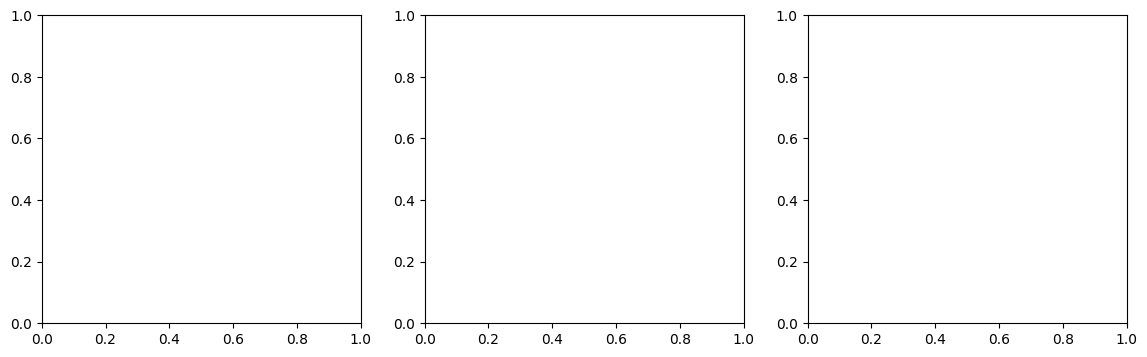

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, field_idx, name in zip(axes, [0,1,2], ['u','v','p']):
    box_data = []
    for Re in RE_LIST:
        f = get_result(Re)
        pred = f(torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32))
        ref  = kovasznay(Re, X, Y)[field_idx]
        box_data.append(np.abs(pred[:,field_idx].numpy().reshape(X.shape) - ref).ravel())
    bp = ax.boxplot(box_data, patch_artist=True, showfliers=False,
                    medianprops=dict(color='k', lw=2))
    for patch, Re in zip(bp['boxes'], RE_LIST):
        patch.set_facecolor('#f4a261' if is_extrap(Re) else '#aec6e8')
    ax.set_yscale('log'); ax.set_xticklabels(RE_LIST, rotation=45)
    ax.set_title(f'Erreur absolue — {name}'); ax.set_xlabel('Re'); ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#aec6e8', label='Interpolation [20–100]'),
    Patch(color='#f4a261', label='Extrapolation'),
], fontsize=9)
plt.tight_layout(); plt.show()

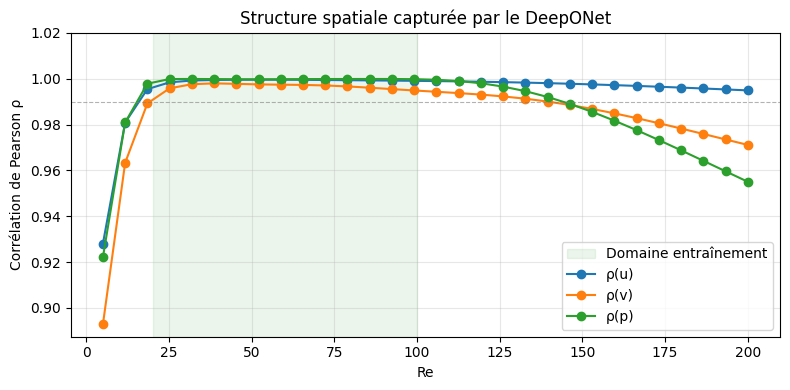

In [27]:
correlations = {'u': [], 'v': [], 'p': []}

for Re in RE_LIST:
    preds = model(
        torch.tensor([Re], dtype=torch.float64),
        torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float64)
    ).detach().squeeze(0).numpy()
    refs = kovasznay(Re, X, Y)
    for i, name in enumerate(['u', 'v', 'p']):
        pred = preds[:, i]
        ref  = refs[i].ravel()
        correlations[name].append(np.corrcoef(pred, ref)[0, 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(20, 100, color='green', alpha=0.08, label='Domaine entraînement')
for field, color in zip(['u','v','p'], ['#1f77b4','#ff7f0e','#2ca02c']):
    ax.plot(RE_LIST, correlations[field], 'o-', color=color, label=f'ρ({field})')
ax.axhline(0.99, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('Re'); ax.set_ylabel('Corrélation de Pearson ρ')
ax.set_title('Structure spatiale capturée par le DeepONet')
ax.set_ylim(None, 1.02)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

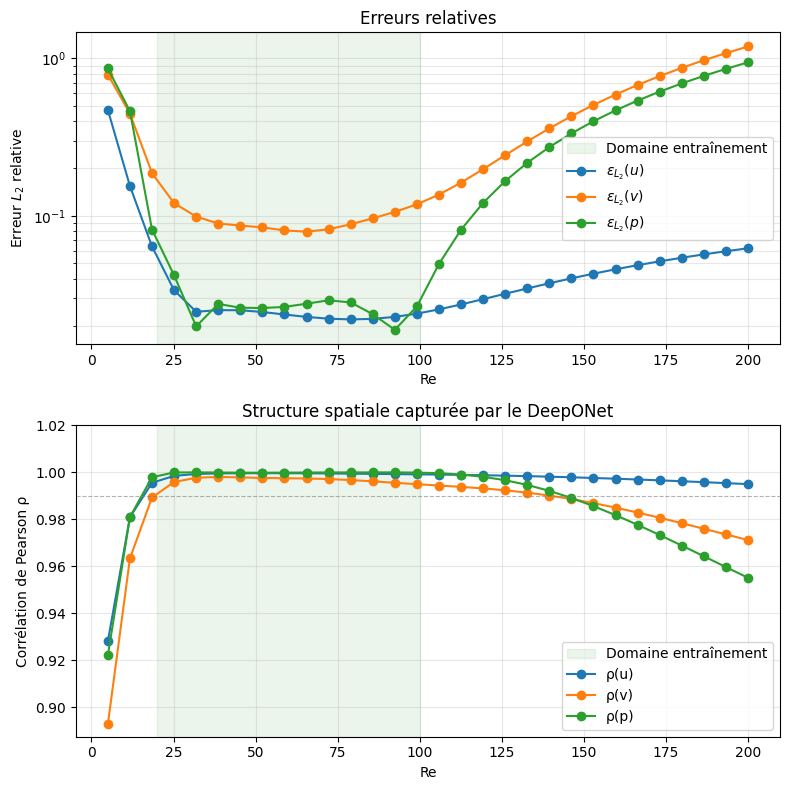

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
# --- Gauche : erreurs L2 ---
ax1.axvspan(20, 100, color='green', alpha=0.08, label='Domaine entraînement')
for field, color in zip(['u','v','p'], ['#1f77b4','#ff7f0e','#2ca02c']):
    ax1.plot(RE_LIST, errors[field], 'o-', color=color, label=f'$\\epsilon_{{L_2}}({field})$')
ax1.set_yscale('log')
ax1.set_xlabel('Re'); ax1.set_ylabel('Erreur $L_2$ relative')
ax1.set_title('Erreurs relatives')
ax1.legend(); ax1.grid(True, which='both', alpha=0.3)

# --- Droite : corrélations ---
correlations = {'u': [], 'v': [], 'p': []}
for Re in RE_LIST:
    preds = model(
        torch.tensor([Re], dtype=torch.float64),
        torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float64)
    ).detach().squeeze(0).numpy()
    refs = kovasznay(Re, X, Y)
    for i, name in enumerate(['u', 'v', 'p']):
        pred = preds[:, i]
        ref  = refs[i].ravel()
        correlations[name].append(np.corrcoef(pred, ref)[0, 1])

ax2.axvspan(20, 100, color='green', alpha=0.08, label='Domaine entraînement')
for field, color in zip(['u','v','p'], ['#1f77b4','#ff7f0e','#2ca02c']):
    ax2.plot(RE_LIST, correlations[field], 'o-', color=color, label=f'ρ({field})')
ax2.axhline(0.99, color='gray', lw=0.8, ls='--', alpha=0.6)
ax2.set_xlabel('Re'); ax2.set_ylabel('Corrélation de Pearson ρ')
ax2.set_title('Structure spatiale capturée par le DeepONet')
ax2.set_ylim(None, 1.02)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

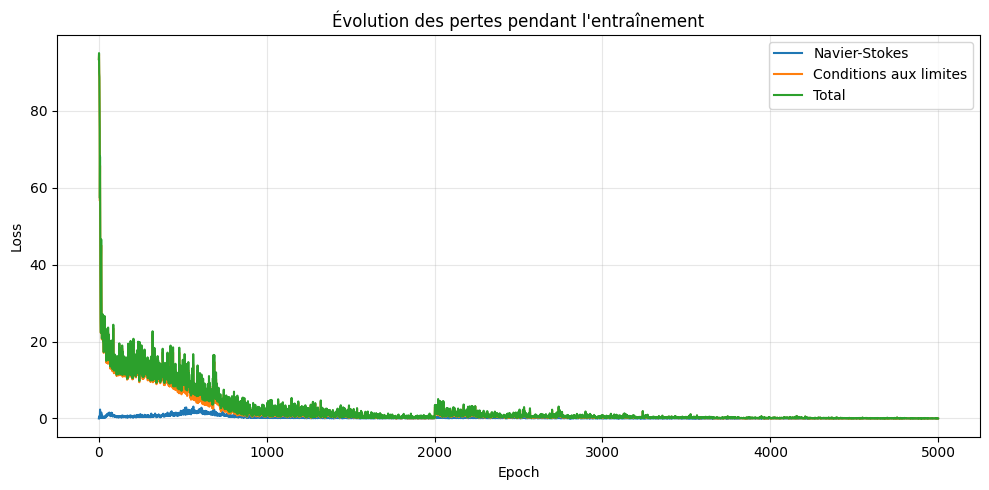

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs = range(len(losses))
labels = ['Navier-Stokes', 'Conditions aux limites', 'Total']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (label, color) in enumerate(zip(labels, colors)):
    ax.plot(epochs, [step[i] for step in losses], color=color, label=label, lw=1.5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Évolution des pertes pendant l\'entraînement')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

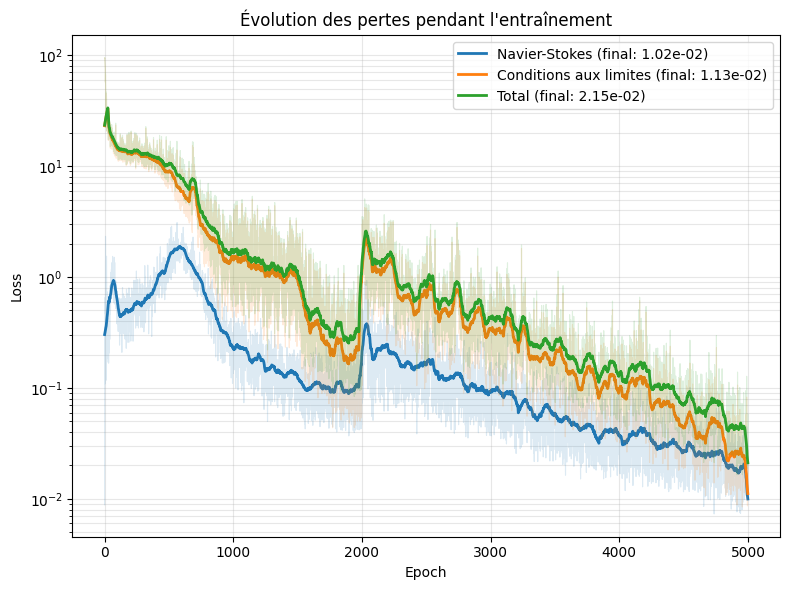

In [42]:
import numpy as np

def smooth(x, w=50):
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode='same')

fig, ax = plt.subplots(figsize=(8, 6))

labels = ['Navier-Stokes', 'Conditions aux limites', 'Total']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
epochs = np.arange(len(losses))
series = [[step[i] for step in losses] for i in range(3)]

for s, label, color in zip(series, labels, colors):
    raw = np.array(s)
    final = raw[-1]
    ax.plot(epochs, raw, color=color, alpha=0.15, lw=0.8)
    ax.plot(epochs, smooth(raw), color=color, lw=2, label=f'{label} (final: {final:.2e})')

ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Évolution des pertes pendant l\'entraînement')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()